# Car Price Prediction with Machine Learning

## Oasis Infobyte Data Science Internship – Task 3

### Objective
The objective of this project is to build a machine learning regression model that predicts the selling price of a used car based on features such as brand, age, mileage, fuel type, transmission, and other relevant factors.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
# Check for missing values
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [4]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (3577, 8)


In [5]:
df["fuel"] = df["fuel"].str.strip().str.title()
df["transmission"] = df["transmission"].str.strip().str.title()

# Check the unique values
print("Fuel types:", df["fuel"].unique())
print("Transmission types:", df["transmission"].unique())

Fuel types: <ArrowStringArray>
['Petrol', 'Diesel', 'Cng', 'Lpg', 'Electric']
Length: 5, dtype: str
Transmission types: <ArrowStringArray>
['Manual', 'Automatic']
Length: 2, dtype: str


In [6]:
# Calculate car age
current_year = 2026
df["car_age"] = current_year - df["year"]
df[["year", "car_age"]].head()

,year,car_age
0,2007,19
1,2007,19
2,2012,14
3,2017,9
4,2014,12


In [7]:
# Extract car brand from car name
df["brand"] = df["name"].str.split().str[0]
df[["name", "brand"]].head()

,name,brand
0,Maruti 800 AC,Maruti
1,Maruti Wagon R LXI Minor,Maruti
2,Hyundai Verna 1.6 SX,Hyundai
3,Datsun RediGO T Option,Datsun
4,Honda Amaze VX i-DTEC,Honda


In [8]:
# Check the updated dataset

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age,brand
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,19,Maruti
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,19,Maruti
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,14,Hyundai
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,9,Datsun
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,12,Honda


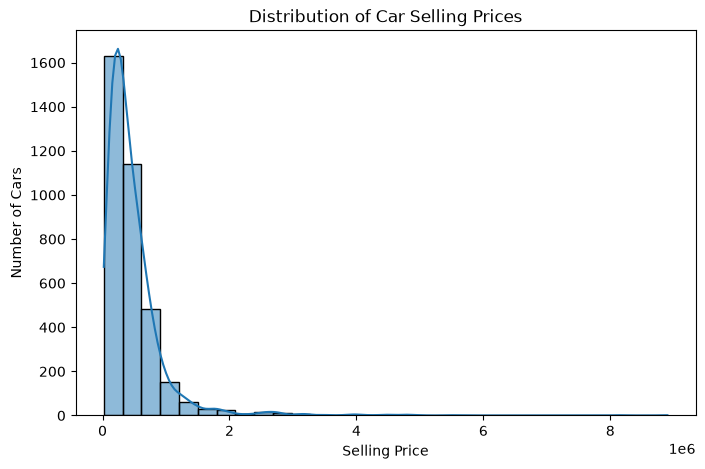

In [9]:
# Distribution of selling prices

plt.figure(figsize=(8, 5))
sns.histplot(df["selling_price"], bins=30, kde=True)

plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.show()

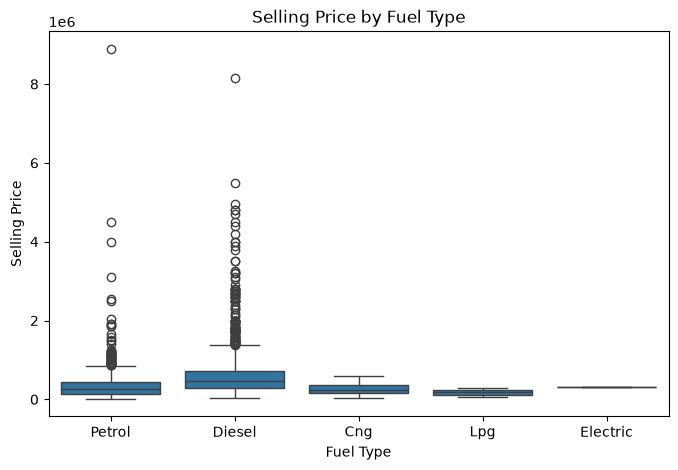

In [10]:
# Selling price by fuel type

plt.figure(figsize=(8, 5))
sns.boxplot(x="fuel", y="selling_price", data=df)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.show()

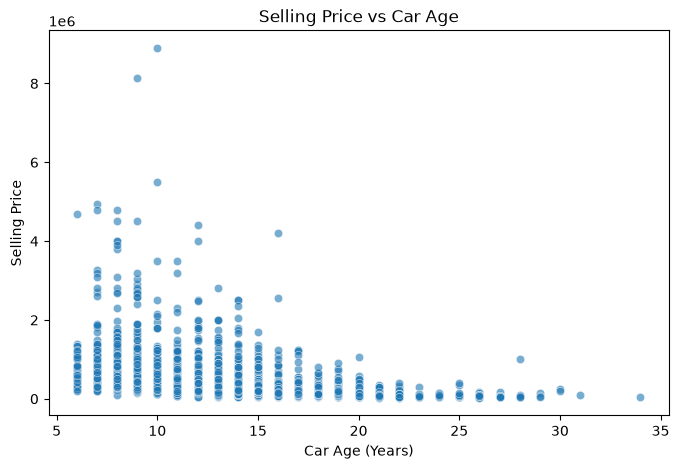

In [11]:
# Selling price vs car age

plt.figure(figsize=(8, 5))
sns.scatterplot(x="car_age", y="selling_price", data=df, alpha=0.6)

plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price")
plt.show()

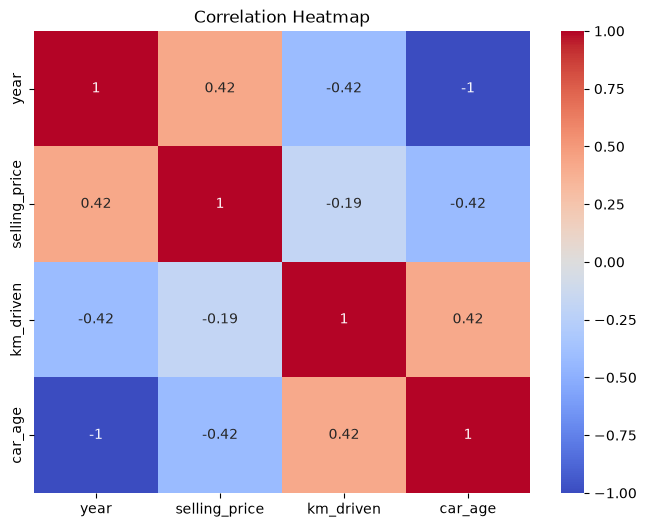

In [12]:
# Correlation heatmap

plt.figure(figsize=(8, 6))
sns.heatmap(
    df[["year", "selling_price", "km_driven", "car_age"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

In [13]:
# Encode all categorical columns

df_encoded = pd.get_dummies(
    df,
    columns=df.select_dtypes(include="object").columns,
    drop_first=True
)

df_encoded.head()

C:\Users\KUNAL\AppData\Local\Temp\ipykernel_3392\1568611622.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columns=df.select_dtypes(include="object").columns,


,year,selling_price,km_driven,car_age,name_Ambassador Classic 2000 Dsz,name_Ambassador Grand 1800 ISZ MPFI PW CL,name_Audi A4 1.8 TFSI,name_Audi A4 2.0 TDI,name_Audi A4 2.0 TDI 177 Bhp Premium Plus,name_Audi A4 3.0 TDI Quattro,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_OpelCorsa,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,2007,60000,70000,19,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2007,135000,50000,19,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2012,600000,100000,14,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2017,250000,46000,9,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2014,450000,141000,12,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [14]:
# Select features and target

X = df_encoded.drop(columns=["selling_price"])
y = df_encoded["selling_price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (3577, 1532)
Target shape: (3577,)


In [15]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2861, 1532)
Testing data: (716, 1532)


In [16]:
X_train.dtypes.value_counts()

bool     1529
int64       3
Name: count, dtype: int64

In [17]:
# Train Linear Regression model

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions
linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [18]:
# Train Random Forest Regressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test)

print("Random Forest Regressor trained successfully.")

Random Forest Regressor trained successfully.


In [19]:
# Evaluate Linear Regression

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression
MAE : 176948.2596414245
RMSE: 385996.6235914089
R²  : 0.53747914848486


In [20]:
# Evaluate Random Forest Regressor

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Regressor")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Regressor
MAE : 135965.9704524918
RMSE: 359121.2835883817
R²  : 0.5996437670137013


In [21]:
# Compare model performance

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R²": [linear_r2, rf_r2]
})
results

,Model,MAE,RMSE,R²
0,Linear Regression,176948.259641,385996.623591,0.537479
1,Random Forest,135965.970452,359121.283588,0.599644


## Model Comparison

The two regression models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

The model with lower MAE and RMSE and higher R² Score is considered the better-performing model.

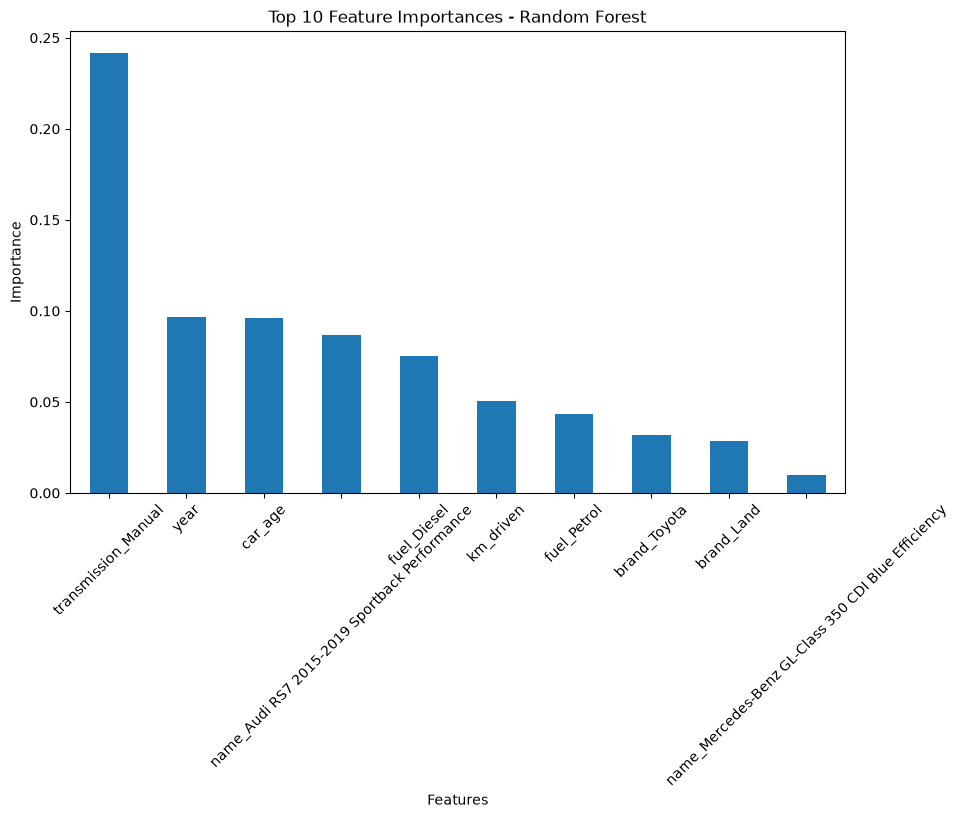

In [22]:
# Feature importance of the Random Forest model

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.head(10).plot(kind="bar")

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

## Conclusion

Two regression models were trained and evaluated for used car price prediction: Linear Regression and Random Forest Regressor.

The Random Forest Regressor performed better than Linear Regression, achieving a higher R² score and lower MAE and RMSE.

The feature importance analysis also helped identify the features that contributed most to predicting car selling prices.

Overall, the Random Forest model provided better price prediction performance on the given dataset.